<h2>Assignment 1</h2>

<table style="width:100%; text-align:left;">
<tr>
<td>

### Student 1  
**Name:** Aakanksha Deshpande  
**Student Id:** 25238088  

</td>

<td>

### Student 2  
**Name:** Vijayalaxmi Hubli  
**Student Id:** 25242017  

</td>
</tr>
</table>


## Task 1: Implement Logistic Regression

In [77]:
# Package imports
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [78]:
# Display plots inline
%matplotlib inline

In [79]:
# Initialising Hyperparameters

# alpha = 0.0001 # learning rate
# max_iterations = 10000
# threshold = 1e-8
# N = 500 # No of iterations

In [80]:
# Sigmoid Function (Activation Function)

def sigmoid(z):
    """
    Implementation of activation function
    Inputs:
    z (linear input)
    Outputs: 
    Binary classification returns probability value between 0 & 1
    """
    return (1 / (1 + (np.exp(-z))))

In [81]:
# Loss function
def compute_loss(y, y_hat):
    """
    Implementation of cross-entropy loss function

    Inputs:
    y = True Label (0 or 1)
    y_hat = Predicted probability (between 0 and 1)

    Output:
    Loss for the classification
    """
    return (- (y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))).item()

In [82]:
# Implementing Logistic Regression Algorithm

def train_logistic_regression(X, Y, alpha, max_iteration, threshold):
    """
    Logistic Regression Learning Algorithm with forward pass and Stochastic Gradient Descent

    Inputs:
    X = training dataset
    Y = target labels
    alpha = learning rate
    max_iteration = no of steps allowed for training
    threshold = stopping criteria

    Outputs:
    w = learned weights
    b = learned bias
    loss = loss calculated at per iteration
    epoch_loss = loss of a single epoch
    """
    #---------------------------------
    # Initialising parameters
    #---------------------------------
    np.random.seed(42)                        # To ensure same results everytime
    stopping = False                          # To exit the while loop once convergence is met
    J_running = 0                             # Represents cumulative loss of an epoch 
    epoch_number = 0                          # To keep a counter of epochs
    J_running_prev = 0                        # Represents previous epoch loss for convergence comparsion
    prev_avg_loss = float("inf")
    iteration = 0                             # To keep a counter of iterations     
    N,m = X.shape                             # N = no: of samples, m = no:of features
    w = np.random.normal(0, 0.01, size=(m,1)) # Small range of w & b choosen to avoid missing minima
    b = 0.01                                 

    #---------------------------------
    # Implementing SGD
    #---------------------------------
    loss = []
    epoch_loss = []
    while not stopping:

        # picking random values from training dataset
        index = np.random.randint(0, N)
        x_i = X[index].reshape(-1,1)
        y_i = Y[index]

        # Implementing Forward propagation stage
        z = np.dot(w.T, x_i) + b
        y_hat = sigmoid(z)

        # Calculate the loss
        J_current = compute_loss(y_i, y_hat)
        loss.append(J_current)
        # Gradient Descent stage: partial deivatives
        dw = (y_hat - y_i) * x_i
        db = y_hat - y_i

        # calculate w and b
        w -= alpha * dw
        b -= alpha * db

        # Checking stopping criteia
        iteration += 1
        J_running += J_current

        if iteration % N == 0:
            epoch_number += 1
            avg_loss = J_running / N
            epoch_loss.append(avg_loss)
            # print("Iteration:", iteration, "Avg Loss:", avg_loss)
            if abs(avg_loss - prev_avg_loss) < threshold:
                print(f"Converged after {epoch_number} epochs ({iteration} iterations)")
                stopping = True
            prev_avg_loss = avg_loss
            J_running = 0
        if iteration  > max_iteration:
            print("Failed to converge!!!")
            stopping = True # Failed to converge
        


    return w, b, loss, epoch_loss


In [83]:
def predict(X, w, b, threshold):
    """
    Implementation of prediction function

    Inputs:
    X = input features (Testing/validation dataset)
    w = weights (calculated at training stage)
    b = bias (also calculated at traing stage)
    threshold = decision threshold to classify 
    
    Outputs:
    Returns predicted class label based on threshold
    """
    z = np.dot(X, w) + b
    y_hat = sigmoid(z)
    return (y_hat >= threshold).astype(int)

## Task 2: Testing on Datasets

In [84]:
def split_data(X, y, random_state = 42):
    '''
    This function splits the entire dataset into 3 sections: train, test, validation
    train_test_split function has the ability to split the dataset into 2 sections initially (train & temp). 
    The temp data is then split again in 2 sections - test & validation.

    Inputs: 
    X, y
    Outputs: 
    X_train, Y_train, X_val, Y_val, X_test, Y_test
    '''
    X_train, X_temp, Y_train, Y_temp = train_test_split(
        X, y, test_size=0.3, random_state=random_state, stratify=y)

    X_val, X_test, Y_val, Y_test = train_test_split(
        X_temp, Y_temp, test_size=0.5, random_state=random_state, stratify=Y_temp)

    return X_train, Y_train, X_val, Y_val, X_test, Y_test

In [85]:
# Loading Dataset 1
# Use pandas to read the CSV file as a dataframe
df1 = pd.read_csv(r"C:\Users\anush\Downloads\blobs600 (1).csv")

# The y values are those labelled 'Class': extract their values
y1 = df1['Class'].values

# The x values are all other columns
del df1['Class']   # drop the 'Class' column from the dataframe
X1 = df1.values     # convert the remaining columns to a numpy array

In [86]:
# Check its dimensions

print(f"The dimensions of the dataset are: {np.shape(X1)}")

The dimensions of the dataset are: (600, 3)


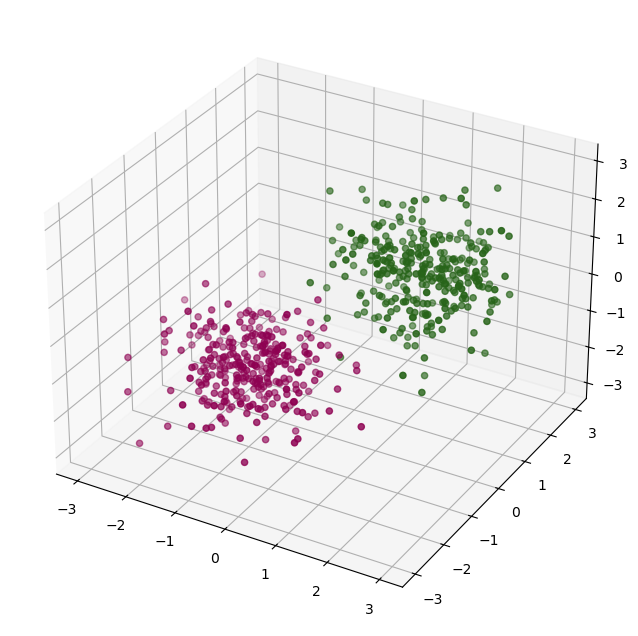

In [87]:
# Plot the dataset in 3D, with colours according to the class label

fig = plt.figure(figsize=(8, 8)) # set the size to 8x8 
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X1[:,0], X1[:,1], X1[:,2], c=y1, cmap="PiYG") # changed the colour map because why not

plt.show()
plt.close(fig)

In [88]:
#Splitting the training data & implementing logistic regression function on Dataset 1

X_train1, Y_train1, X_val1, Y_val1, X_test1, Y_test1 = split_data(X1, y1)
w1, b1, loss1, epoch_loss1 = train_logistic_regression(X_train1, Y_train1, alpha=0.01, max_iteration=20000, threshold=1e-3)
print(w1, b1, epoch_loss1)

Converged after 5 epochs (2100 iterations)
[[1.4913422 ]
 [1.28627418]
 [1.32349131]] [[-0.00392804]] [0.22564382348108486, 0.08648357526916561, 0.05680247064224819, 0.04308129438218171, 0.042499466083714736]


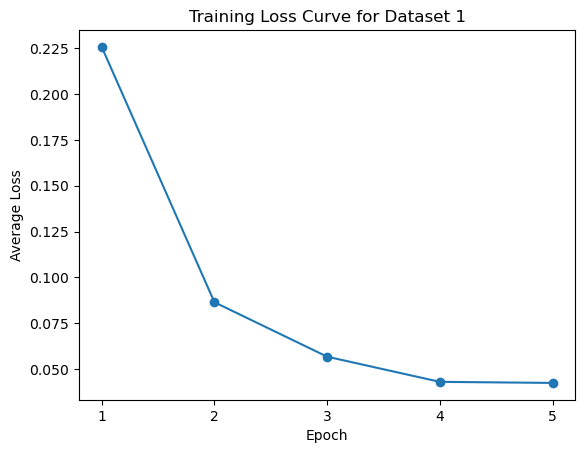

In [89]:
# plotting the Avg_Loss v/s Epoch on Training data for Dataset 1

plt.plot(range(1, len(epoch_loss1)+1), epoch_loss1, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss Curve for Dataset 1")
plt.xticks(range(1, len(epoch_loss1)+1))
plt.show()

In [90]:
#implementing logistic regression function on Test data (Dataset 1)

test_w1, test_b1, test_loss1, test_epoch_loss1 = train_logistic_regression(X_test1, Y_test1, alpha=0.01, max_iteration=20000, threshold=1e-3)
print(test_w1, test_b1, test_epoch_loss1 )

Converged after 23 epochs (2070 iterations)
[[1.23874221]
 [1.41175115]
 [1.44380182]] [[0.05852494]] [0.45121652649575017, 0.25786924613554946, 0.15760244683124724, 0.13659224542906773, 0.12817424285964193, 0.08571970860002308, 0.08983851833983633, 0.08010750254676655, 0.06484724641206412, 0.05752403166898077, 0.06372891985684621, 0.06061849869267244, 0.05285569240810323, 0.045215698217615584, 0.037439024769457034, 0.033089467177136345, 0.03449992197071085, 0.040239886894227535, 0.03708797802902035, 0.04259608006157913, 0.03229614639225322, 0.03714034409645749, 0.036676373133749614]


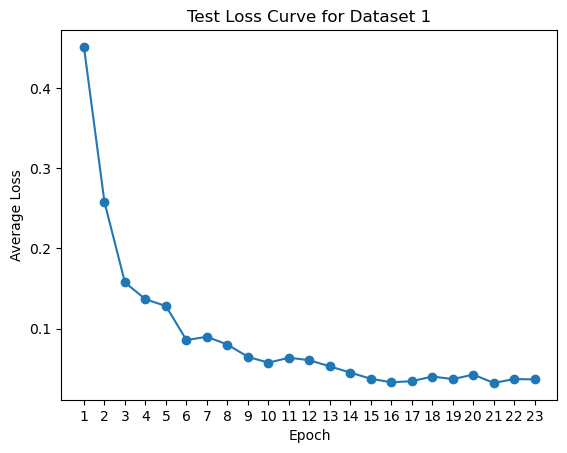

In [91]:
# plotting the Avg_Loss v/s Epoch on Test data for Dataset 1
plt.plot(range(1, len(test_epoch_loss1 )+1), test_epoch_loss1 , marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Test Loss Curve for Dataset 1")
plt.xticks(range(1, len(test_epoch_loss1 )+1))
plt.show()

In [92]:
#implementing logistic regression function on Validation data (Dataset 1)

val_w1, val_b1, val_loss1, val_epoch_loss1 = train_logistic_regression(X_val1, Y_val1, alpha=0.01, max_iteration=20000, threshold=1e-3)
print(val_w1, val_b1, val_epoch_loss1 )

Converged after 50 epochs (4500 iterations)
[[2.10920666]
 [1.57132778]
 [1.3430171 ]] [[-0.01361019]] [0.4631266005593651, 0.2511843516052567, 0.17568464000685746, 0.14520680884827183, 0.09595089848145225, 0.12634022175080092, 0.0914770832699346, 0.08248988252421609, 0.09606283222995457, 0.07346486367850685, 0.0755205002759424, 0.07283609013898015, 0.07507175628197456, 0.05970002187220342, 0.042860635282953495, 0.07876808460060611, 0.05986733431047771, 0.06767872900277375, 0.053216177479714716, 0.06466237619863209, 0.053256559593848146, 0.04821734788831197, 0.08779289138239675, 0.05755267034985075, 0.04527742033202712, 0.03534252232667178, 0.06182663403492892, 0.03225609529689441, 0.045152549539559404, 0.054162534733330346, 0.03622476553302744, 0.06418419478496576, 0.04722667890636848, 0.027873111889518767, 0.046540053414488254, 0.04481414709531353, 0.03293415185552545, 0.026957192367220825, 0.02908123704664835, 0.020067820697851627, 0.030483395825969723, 0.03528747030499535, 0.039530

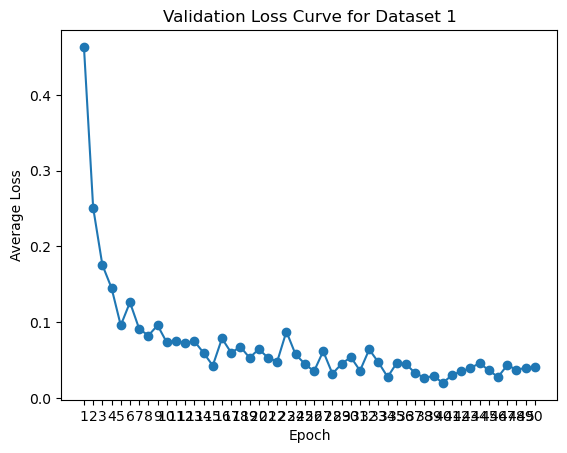

In [93]:
# plotting the Avg_Loss v/s Epoch on Validate data for Dataset 2
plt.plot(range(1, len(val_epoch_loss1 )+1), val_epoch_loss1 , marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Validation Loss Curve for Dataset 1")
plt.xticks(range(1, len(val_epoch_loss1 )+1))
plt.show()

In [94]:
# Validate and test performance
y1_val_pred = predict(X_val1, w1, b1, threshold = 0.5)
val_accuracy = np.mean(y1_val_pred == Y_val1) * 100
print(f"Validation Accuracy: {val_accuracy:.2f}%")
    
y1_test_pred = predict(X_test1, w1, b1, threshold = 0.5)
test_accuracy = np.mean(y1_test_pred == Y_test1) * 100
print(f"Test Accuracy: {test_accuracy:.2f}%")

Validation Accuracy: 50.00%
Test Accuracy: 50.00%


In [95]:
# Loading Dataset 2
# Use pandas to read the CSV file as a dataframe
df2 = pd.read_csv(r"C:\Users\anush\Downloads\circles500 (1).csv")

# The y values are those labelled 'Class': extract their values
y2 = df2['Class'].values

# The x values are all other columns
del df2['Class']   # drop the 'Class' column from the dataframe
X2 = df2.values     # convert the remaining columns to a numpy array

In [96]:
# Check its dimensions

print(f"The dimensions of Dataset 2 are: {np.shape(X2)}")

The dimensions of Dataset 2 are: (500, 2)


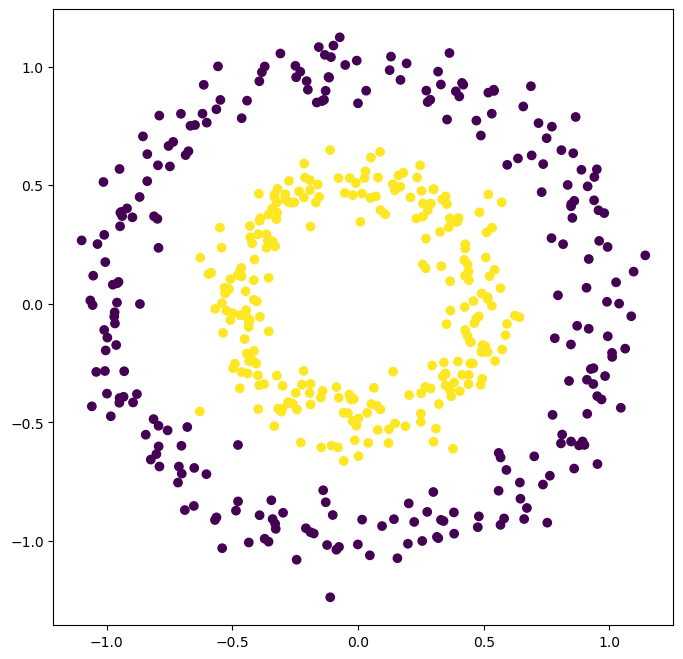

In [97]:
# plot X[0] vs X[1] and colour points according to the class, y

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(X2[:,0], X2[:,1], c=y2)

plt.show()
plt.close(fig)

In [98]:
#Splitting the training data & implementing logistic regression function on Dataset 2

X_train2, Y_train2, X_val2, Y_val2, X_test2, Y_test2 = split_data(X2, y2)
w2, b2, loss2, epoch_loss2 = train_logistic_regression(X_train2, Y_train2, alpha=0.01, max_iteration=30000, threshold=1e-3)
print(w2, b2, epoch_loss2)

Converged after 6 epochs (2100 iterations)
[[ 0.00310505]
 [-0.11872224]] [[-0.0215474]] [0.6925089447815246, 0.6969922965110436, 0.6910863027247911, 0.6950824264293287, 0.6939740883415605, 0.6938309558136733]


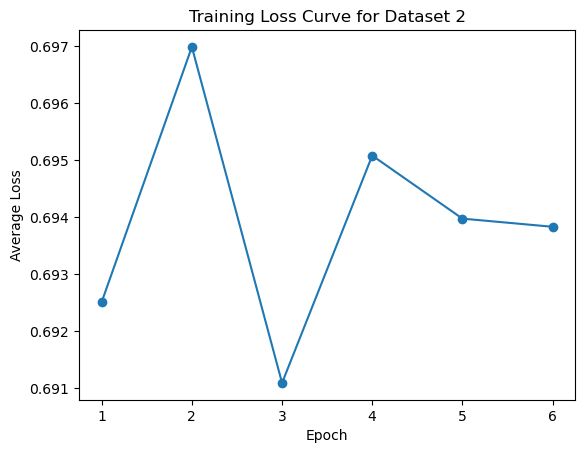

In [99]:
# plotting the Avg_Loss v/s Epoch on Training data for Dataset 2
plt.plot(range(1, len(epoch_loss2)+1), epoch_loss2, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss Curve for Dataset 2")
plt.xticks(range(1, len(epoch_loss2)+1))
plt.show()

In [100]:
#implementing logistic regression function on Test data (Dataset 2)

test_w2, test_b2, test_loss2, test_epoch_loss2 = train_logistic_regression(X_test2, Y_test2, alpha=0.01, max_iteration=30000, threshold=1e-3)
print(test_w2, test_b2, test_epoch_loss2 )

Converged after 12 epochs (900 iterations)
[[-0.04943391]
 [ 0.29452545]] [[-3.38595738e-05]] [0.6926003212783644, 0.6855378443927986, 0.6939936366191359, 0.6975919024685802, 0.6819073110571929, 0.6771306705084529, 0.687065278426251, 0.6705809541205677, 0.6899457215345072, 0.7062243157405588, 0.6852402577546429, 0.6860077081967855]


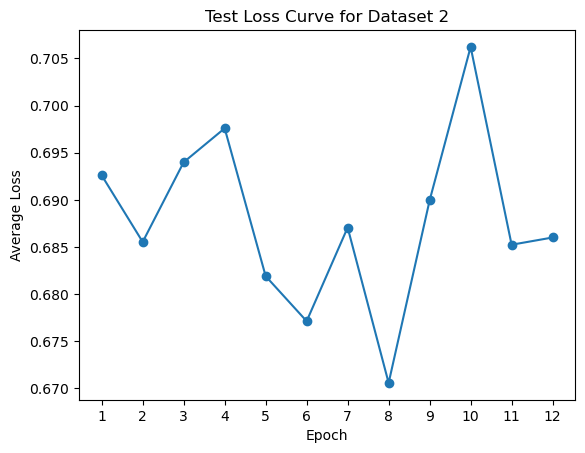

In [101]:
# plotting the Avg_Loss v/s Epoch on Test data for Dataset 2
plt.plot(range(1, len(test_epoch_loss2 )+1), test_epoch_loss2 , marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Test Loss Curve for Dataset 2")
plt.xticks(range(1, len(test_epoch_loss2 )+1))
plt.show()

In [102]:
#implementing logistic regression function on Validation data (Dataset 2)

val_w2, val_b2, val_loss2, val_epoch_loss2 = train_logistic_regression(X_val2, Y_val2, alpha=0.01, max_iteration=30000, threshold=1e-3)
print(val_w2, val_b2, val_epoch_loss2 )

Converged after 13 epochs (975 iterations)
[[0.06372969]
 [0.28471188]] [[0.15292065]] [0.6927811145031175, 0.6953641325845062, 0.692170934884475, 0.6891367455856537, 0.6869631195882694, 0.699701244758171, 0.68830165731672, 0.6943925228724417, 0.6814932836877612, 0.6879592695677276, 0.6817675827665258, 0.6769507997494212, 0.6772842074216765]


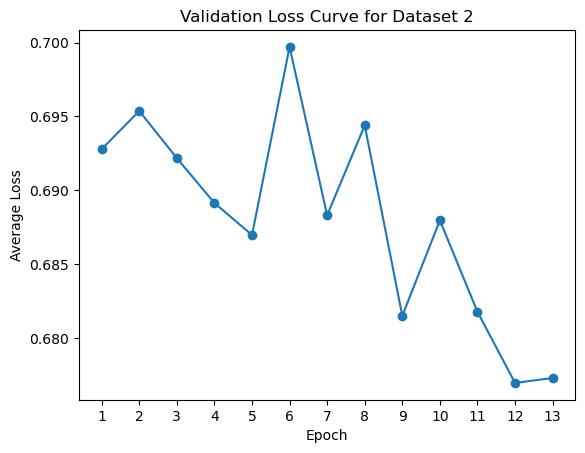

In [103]:
# plotting the Avg_Loss v/s Epoch on Validate data for Dataset 2
plt.plot(range(1, len(val_epoch_loss2 )+1), val_epoch_loss2 , marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Validation Loss Curve for Dataset 2")
plt.xticks(range(1, len(val_epoch_loss2 )+1))
plt.show()

In [104]:
# Validate and test performance
y2_val_pred = predict(X_val2, w2, b2, threshold = 1e-3)
val_accuracy = np.mean(y2_val_pred == Y_val2) * 100
print(f"Validation Accuracy: {val_accuracy:.2f}%")

y2_test_pred = predict(X_test2, w2, b2, threshold = 1e-3)
test_accuracy = np.mean(y2_test_pred == Y_test2) * 100
print(f"Test Accuracy: {test_accuracy:.2f}%")

Validation Accuracy: 50.67%
Test Accuracy: 49.33%


## Task 3: Implement and test a shallow Neural Network

In [105]:
def sigmoid_derivative(a):
    return a * (1 - a)

In [106]:
def initialize_network(n_inputs, n_hidden):
    np.random.seed(42)
    params = {}
    params['W1'] = np.random.randn(n_hidden, n_inputs) * 0.01
    params['b1'] = np.zeros((n_hidden, 1))
    params['W2'] = np.random.randn(1, n_hidden) * 0.01
    params['b2'] = np.zeros((1, 1))
    return params

In [107]:
def forward(x, params):
    z1 = np.dot(params['W1'], x) + params['b1']
    a1 = sigmoid(z1)
    z2 = np.dot(params['W2'], a1) + params['b2']
    a2 = sigmoid(z2)
    cache = {'x': x, 'z1': z1, 'a1': a1, 'z2': z2, 'a2': a2}
    return a2, cache

In [108]:
def backward(y, params, cache, learning_rate):
    x = cache['x']
    a1 = cache['a1']
    a2 = cache['a2']

    dz2 = a2 - y
    dW2 = np.dot(dz2, a1.T)
    db2 = dz2

    dz1 = np.dot(params['W2'].T, dz2) * sigmoid_derivative(a1)
    dW1 = np.dot(dz1, x.T)
    db1 = dz1

    # Update
    params['W2'] -= learning_rate * dW2
    params['b2'] -= learning_rate * db2
    params['W1'] -= learning_rate * dW1
    params['b1'] -= learning_rate * db1

    return params

In [129]:
def train_network(X, Y, n_hidden=2, learning_rate=0.001, epochs=1000, tolerance=1e-6):
    n_inputs = X.shape[0]
    params = initialize_network(n_inputs, n_hidden)
    m = X.shape[1]
    losses = []

    prev_loss = float('inf')
    converged_epoch = None

    for epoch in range(epochs):
        epoch_loss = 0

        for i in range(m):
            x = X[:, i:i+1]
            y = Y[:, i:i+1]

            a2, cache = forward(x, params)
            params = backward(y, params, cache, learning_rate)

            epsilon = 1e-8
            a2_clipped = np.clip(a2, epsilon, 1 - epsilon)
            loss_value = - (y * np.log(a2_clipped) + (1 - y) * np.log(1 - a2_clipped))
            epoch_loss += loss_value.item()

        loss_avg = epoch_loss / m
        losses.append(loss_avg)

        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1}, Loss: {loss_avg:.6f}")

        # Convergence Check
        if abs(prev_loss - loss_avg) < tolerance:
            converged_epoch = epoch + 1
            print(f"\nConverged at epoch {converged_epoch} with Loss: {loss_avg:.6f}")
            break

        prev_loss = loss_avg

    return params, losses, converged_epoch


In [130]:
def predict(X, params):
    m = X.shape[1]
    predictions = np.zeros((1, m))
    for i in range(m):
        x = X[:, i:i+1]
        a2, _ = forward(x, params)
        predictions[0, i] = 1 if a2 > 0.5 else 0
    return predictions

In [131]:


X_blobs_train = X_train1.T  # shape: (n_features, n_samples)
# # Labels: Class
Y_blobs_train = Y_train1.reshape(1,-1)


In [133]:
params_blobs_train, losses_blobs_train, converged_epoch = train_network(
    X_blobs_train, 
    Y_blobs_train, 
    n_hidden=3, 
    learning_rate=0.001, 
    epochs=50000
)


Epoch 100, Loss: 0.155883
Epoch 200, Loss: 0.043010
Epoch 300, Loss: 0.027214
Epoch 400, Loss: 0.021149
Epoch 500, Loss: 0.017923
Epoch 600, Loss: 0.015903
Epoch 700, Loss: 0.014510
Epoch 800, Loss: 0.013486
Epoch 900, Loss: 0.012701
Epoch 1000, Loss: 0.012078
Epoch 1100, Loss: 0.011571
Epoch 1200, Loss: 0.011151
Epoch 1300, Loss: 0.010797
Epoch 1400, Loss: 0.010495
Epoch 1500, Loss: 0.010233
Epoch 1600, Loss: 0.010005
Epoch 1700, Loss: 0.009804
Epoch 1800, Loss: 0.009625
Epoch 1900, Loss: 0.009466
Epoch 2000, Loss: 0.009322
Epoch 2100, Loss: 0.009193
Epoch 2200, Loss: 0.009075
Epoch 2300, Loss: 0.008968

Converged at epoch 2330 with Loss: 0.008938


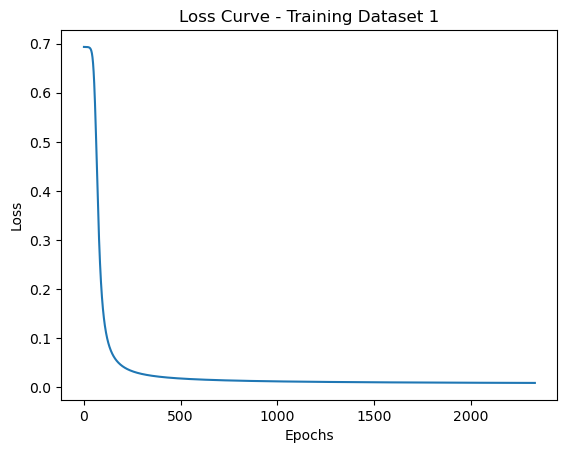

In [134]:
plt.plot(range(1, len(losses_blobs_train) + 1), losses_blobs_train)
plt.title("Loss Curve - Training Dataset 1")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()


In [135]:
X_blobs_test = X_test1.T 
Y_blobs_test = Y_test1.reshape(1,-1)
X_blobs_val = X_val1.T 
Y_blobs_val = Y_val1.reshape(1,-1)

In [136]:
y_test_pred1 = predict(X_blobs_test, params_blobs_train)
SNN_test_accuracy1 = np.mean(y_test_pred1 == Y_blobs_test) * 100
print(f"Test Accuracy: {SNN_test_accuracy1:.2f}%")

Test Accuracy: 100.00%


In [137]:
params_blobs_test, losses_blobs_test, converged_epoch = train_network(
    X_blobs_test, 
    Y_blobs_test, 
    n_hidden=3, 
    learning_rate=0.01, 
    epochs=50000
)



Converged at epoch 4 with Loss: 0.695218


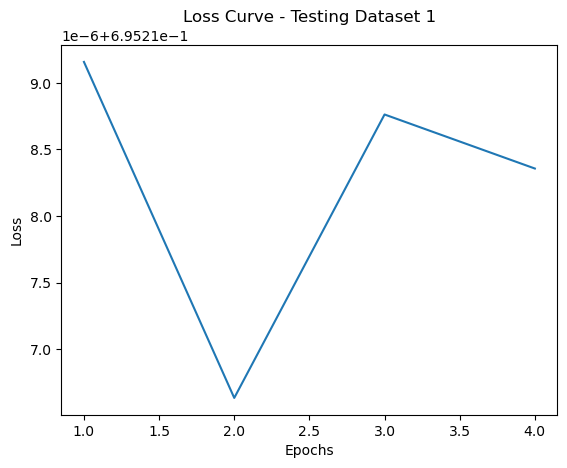

In [138]:

plt.plot(range(1, len(losses_blobs_test) + 1), losses_blobs_test)
plt.title("Loss Curve - Testing Dataset 1")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()


In [139]:
y_val_pred1 = predict(X_blobs_val, params_blobs_train)
SNN_val_accuracy1 = np.mean(y_val_pred1 == Y_blobs_val) * 100
print(f"Validation Accuracy: {SNN_val_accuracy1:.2f}%")

Validation Accuracy: 98.89%


In [140]:
params_blobs_val, losses_blobs_val, converged_epoch = train_network(
    X_blobs_val, 
    Y_blobs_val, 
    n_hidden=3, 
    learning_rate=0.001, 
    epochs=50000
)


Epoch 100, Loss: 0.692918
Epoch 200, Loss: 0.675019
Epoch 300, Loss: 0.488396
Epoch 400, Loss: 0.248083
Epoch 500, Loss: 0.143886
Epoch 600, Loss: 0.099303
Epoch 700, Loss: 0.075967
Epoch 800, Loss: 0.061899
Epoch 900, Loss: 0.052580
Epoch 1000, Loss: 0.045984
Epoch 1100, Loss: 0.041080
Epoch 1200, Loss: 0.037294
Epoch 1300, Loss: 0.034281
Epoch 1400, Loss: 0.031824
Epoch 1500, Loss: 0.029779
Epoch 1600, Loss: 0.028048
Epoch 1700, Loss: 0.026559
Epoch 1800, Loss: 0.025264
Epoch 1900, Loss: 0.024125
Epoch 2000, Loss: 0.023112
Epoch 2100, Loss: 0.022204
Epoch 2200, Loss: 0.021385
Epoch 2300, Loss: 0.020640
Epoch 2400, Loss: 0.019959
Epoch 2500, Loss: 0.019333
Epoch 2600, Loss: 0.018754
Epoch 2700, Loss: 0.018217
Epoch 2800, Loss: 0.017717
Epoch 2900, Loss: 0.017249
Epoch 3000, Loss: 0.016810
Epoch 3100, Loss: 0.016397
Epoch 3200, Loss: 0.016007
Epoch 3300, Loss: 0.015639
Epoch 3400, Loss: 0.015289
Epoch 3500, Loss: 0.014957
Epoch 3600, Loss: 0.014641
Epoch 3700, Loss: 0.014339
Epoch 3800

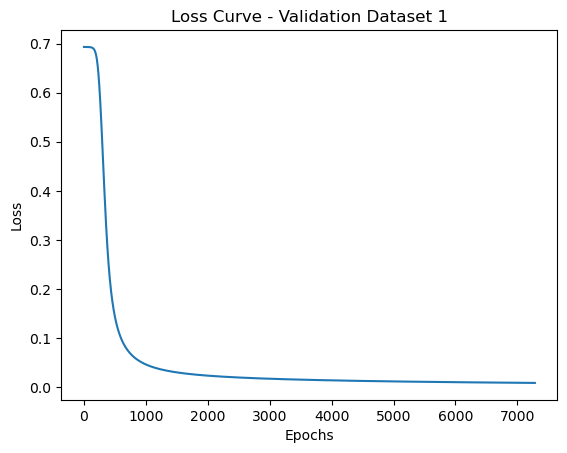

In [141]:


plt.plot(range(1, len(losses_blobs_val) + 1), losses_blobs_val)
plt.title("Loss Curve - Validation Dataset 1")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

### Implementing SNN on Dataset 2 (Non-linearly separable data)

In [144]:

X_circles_train = X_train2.T
Y_circles_train = Y_train2.reshape(1,-1)

In [145]:
params_circles, losses_circles,  converged_epoch= train_network(X_circles_train, Y_circles_train,
                                  n_hidden=3,
                                  learning_rate=0.001,
                                  epochs=20000)


Converged at epoch 5 with Loss: 0.693369


In [146]:
pred_circles = predict(X_circles, params_circles)

In [147]:
print("Accuracy:", np.mean(pred_circles == Y_circles) * 100)

Accuracy: 50.0


In [148]:
print("Predictions:", pred_circles)
print("Actual     :", Y_circles)

Predictions: [[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1.

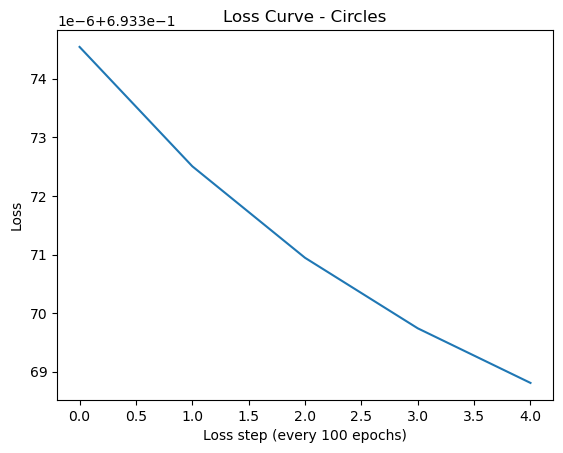

In [149]:
plt.plot(losses_circles)
plt.title("Loss Curve - Circles")
plt.xlabel("Loss step (every 100 epochs)")
plt.ylabel("Loss")
plt.show()

In [150]:
X_val2_T = X_val2.T
Y_val2_T = Y_val2.reshape(1, -1)

In [151]:
params_val2, epoch_loss2,  converged_epoch = train_network(
    X_val2_T, 
    Y_val2_T, 
    n_hidden=3, 
    learning_rate=0.001, 
    epochs=20000
)


Converged at epoch 16 with Loss: 0.693285


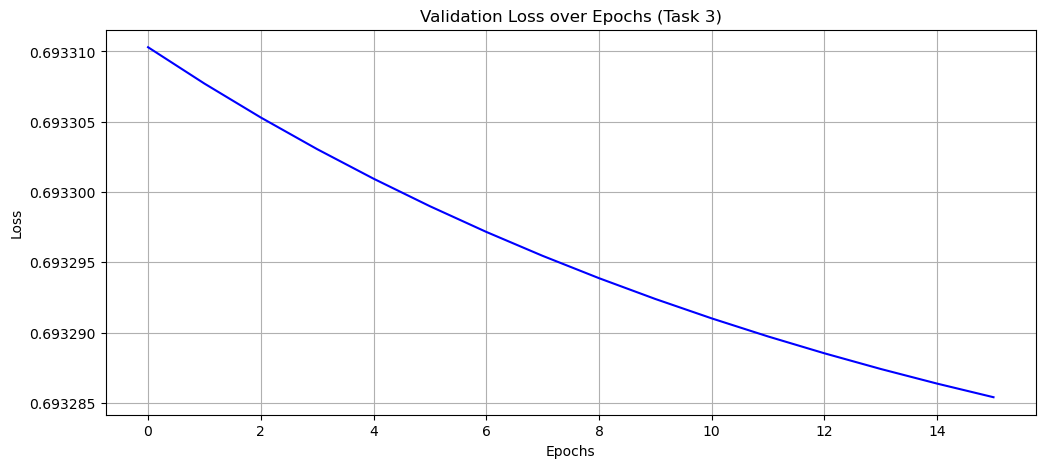

In [152]:
plt.figure(figsize=(12,5))
plt.plot(epoch_loss2, color='blue')
plt.title("Validation Loss over Epochs (Task 3)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [153]:
y_val_pred = predict(X_val2_T, params_circles)
val_accuracy = np.mean(y_val_pred == Y_val2_T) * 100
print(f"Validation Accuracy: {val_accuracy:.2f}%")

Validation Accuracy: 50.67%


In [154]:
X_test2_T = X_test2.T
Y_test2_T = Y_test2.reshape(1, -1)

In [155]:
params_test2, epoch_loss_test2,  converged_epoch = train_network(
   X_test2_T, 
    Y_test2_T , 
    n_hidden=50, 
    learning_rate=0.01, 
    epochs=20000
)

Epoch 100, Loss: 0.708791
Epoch 200, Loss: 0.708362
Epoch 300, Loss: 0.707282
Epoch 400, Loss: 0.704723
Epoch 500, Loss: 0.701626
Epoch 600, Loss: 0.700287
Epoch 700, Loss: 0.699861
Epoch 800, Loss: 0.699511
Epoch 900, Loss: 0.699084
Epoch 1000, Loss: 0.698489
Epoch 1100, Loss: 0.697481
Epoch 1200, Loss: 0.695177
Epoch 1300, Loss: 0.688077
Epoch 1400, Loss: 0.667769
Epoch 1500, Loss: 0.636606
Epoch 1600, Loss: 0.609339
Epoch 1700, Loss: 0.581356
Epoch 1800, Loss: 0.542511
Epoch 1900, Loss: 0.507676
Epoch 2000, Loss: 0.485836
Epoch 2100, Loss: 0.473249
Epoch 2200, Loss: 0.465341
Epoch 2300, Loss: 0.457545
Epoch 2400, Loss: 0.434922
Epoch 2500, Loss: 0.363863
Epoch 2600, Loss: 0.261198
Epoch 2700, Loss: 0.188531
Epoch 2800, Loss: 0.147193
Epoch 2900, Loss: 0.121791
Epoch 3000, Loss: 0.104628
Epoch 3100, Loss: 0.092276
Epoch 3200, Loss: 0.082980
Epoch 3300, Loss: 0.075739
Epoch 3400, Loss: 0.069940
Epoch 3500, Loss: 0.065188
Epoch 3600, Loss: 0.061220
Epoch 3700, Loss: 0.057853
Epoch 3800

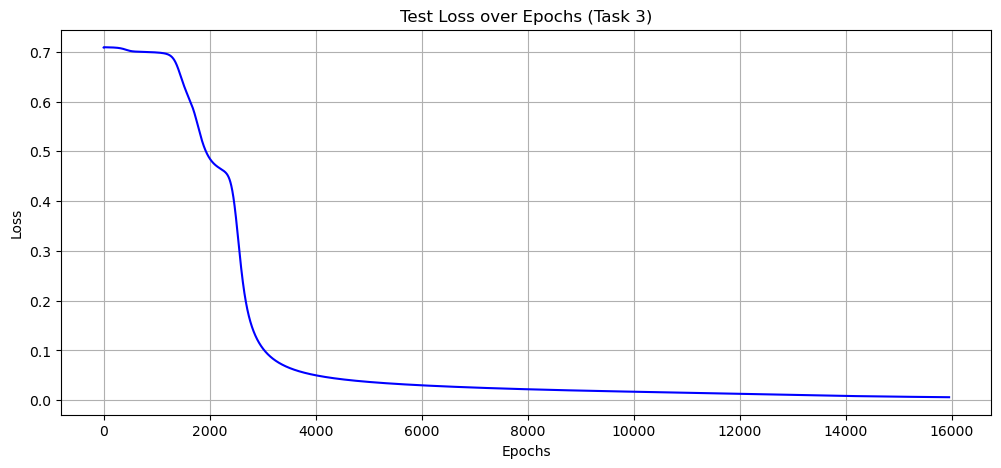

In [156]:
plt.figure(figsize=(12,5))
plt.plot(epoch_loss_test2, color='blue')
plt.title("Test Loss over Epochs (Task 3)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [157]:
y_test_pred = predict( X_test2_T, params_circles)
test_accuracy = np.mean(y_test_pred == Y_test2_T) * 100
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 49.33%


In [159]:

X_circles = X_train2.T      
Y_circles = Y_train2.reshape(1, -1)  

X_val_circles = X_val2.T
Y_val_circles = Y_val2.reshape(1, -1)

X_test_circles = X_test2.T
Y_test_circles = Y_test2.reshape(1, -1)

params, losses,  converged_epoch = train_network(
    X_circles, 
    Y_circles, 
    n_hidden=5, 
    learning_rate=0.01, 
    epochs=2000
)

def compute_accuracy(X, Y, params, name=""):
    pred = predict(X, params)
    acc = np.mean(pred == Y) * 100
    print(f"{name} Accuracy: {acc:.2f}%")
    return acc

train_acc = compute_accuracy(X_circles, Y_circles, params, "Train")
val_acc   = compute_accuracy(X_val_circles, Y_val_circles, params, "Validation")
test_acc  = compute_accuracy(X_test_circles, Y_test_circles, params, "Test")


Converged at epoch 5 with Loss: 0.695792
Train Accuracy: 50.00%
Validation Accuracy: 50.67%
Test Accuracy: 49.33%


## Task 4: Tackle a challenging task

In [54]:
data = np.load(r"C:\Users\anush\Downloads\emnist_letters_85800.npz")
x_data = data["x"]
y_data = data["y"]

In [55]:
# Do some data checks ...

# Check how many different classes we have: should be 26
n_classes =len(np.unique(y_data))
print(f"The number of unique classes is {n_classes} (should be 26).")

# check that images are scaled: min should be 0, max should be 1
img = x_data[0]
print(f"\nFor a single image, the min value is {img.min()} and the max is {img.max()} (should be 0.0 and 1.0).")

# Check the shape of the two classes
print(f"\nShape of x_data is {x_data.shape}, shape of y_data is {y_data.shape} (should have 85,800 cases and x should be 28x28).")

The number of unique classes is 26 (should be 26).

For a single image, the min value is 0.0 and the max is 1.0 (should be 0.0 and 1.0).

Shape of x_data is (85800, 28, 28, 1), shape of y_data is (85800,) (should have 85,800 cases and x should be 28x28).


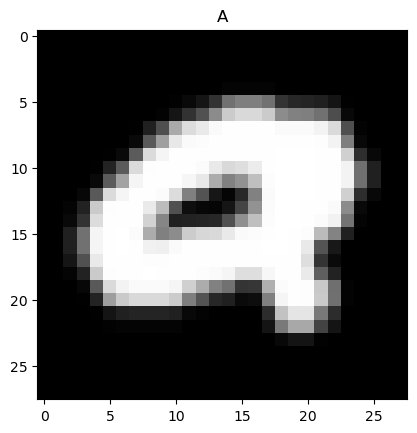

In [56]:
# Plot the first image

plt.imshow(x_data[0].squeeze(), cmap="gray")
plt.title(chr(int(y_data[0]) + 64))  
plt.show()

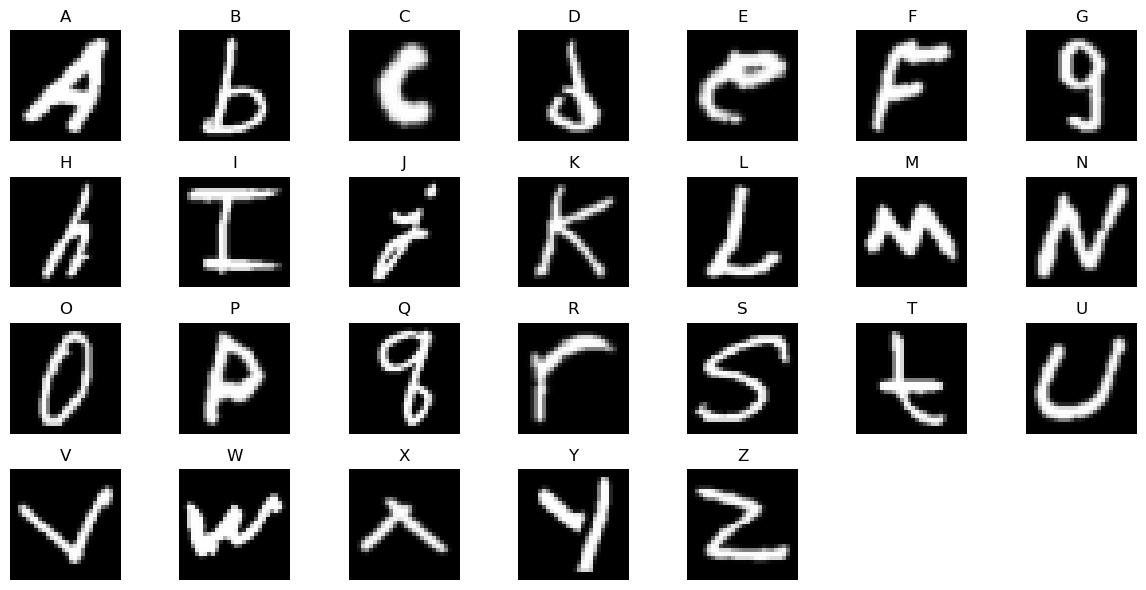

In [57]:
# Plot one item per class
n = 1000  # plot the n-th item, starting from 0

# Get unique labels
classes = np.unique(y_data)

plt.figure(figsize=(12, 6))

for i, cls in enumerate(classes):
    # Find first index of this class
    idx = np.where(y_data == cls)[0][n]
    
    plt.subplot(4, 7, i + 1)
    plt.imshow(x_data[idx].squeeze(), cmap="gray")
    plt.title(chr(int(cls) + 64))  # 1->A, 2->B, ...
    plt.axis("off")

plt.tight_layout()
plt.show()

In [58]:
# Extract just two classes from the dataset

# PUT YOUR OWN CLASS NUMBERS HERE: remember that A=1, z=26.
c1 = 1   # example
c2 = 18  # example

mask = (y_data == c1) | (y_data == c2)

x_binary = x_data[mask]
y_binary = y_data[mask]

# Now change labels to 0 and 1
y_binary = (y_binary == c2).astype(int)

In [59]:
# To help you examine your data, here is a graph to plot 48  images in a grid, starting from an index you specify.

def plot_grid(x, y, n):
    plt.figure(figsize=(12, 10))
    
    for i in range(48):
        idx = n + i
        
        plt.subplot(6, 8, i + 1)
        plt.imshow(x[idx].squeeze(), cmap="gray")
        plt.title(int(y[idx]))
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

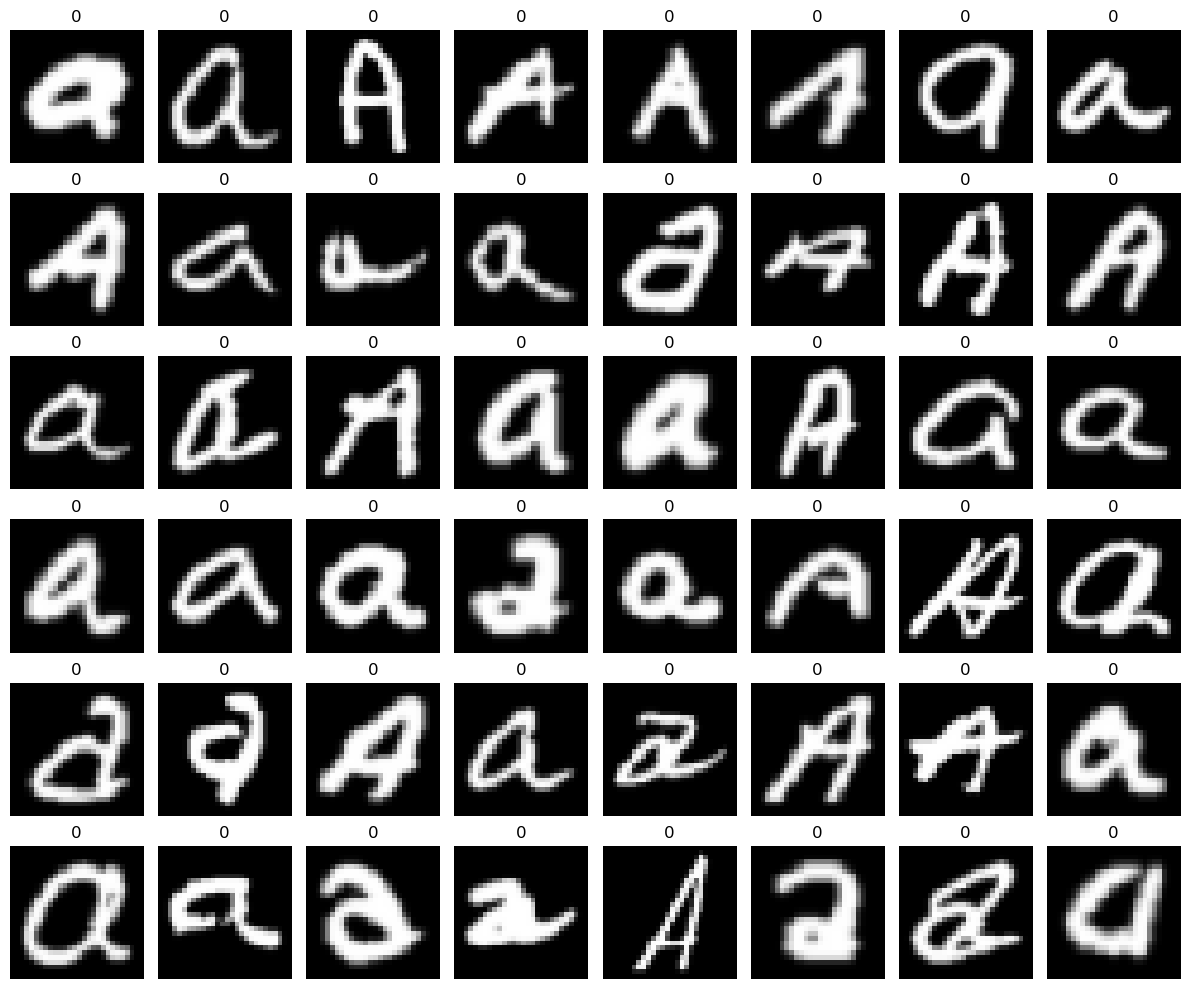

In [60]:
# Let's check images at the start - will all have label 0

plot_grid(x_binary, y_binary, n=0)

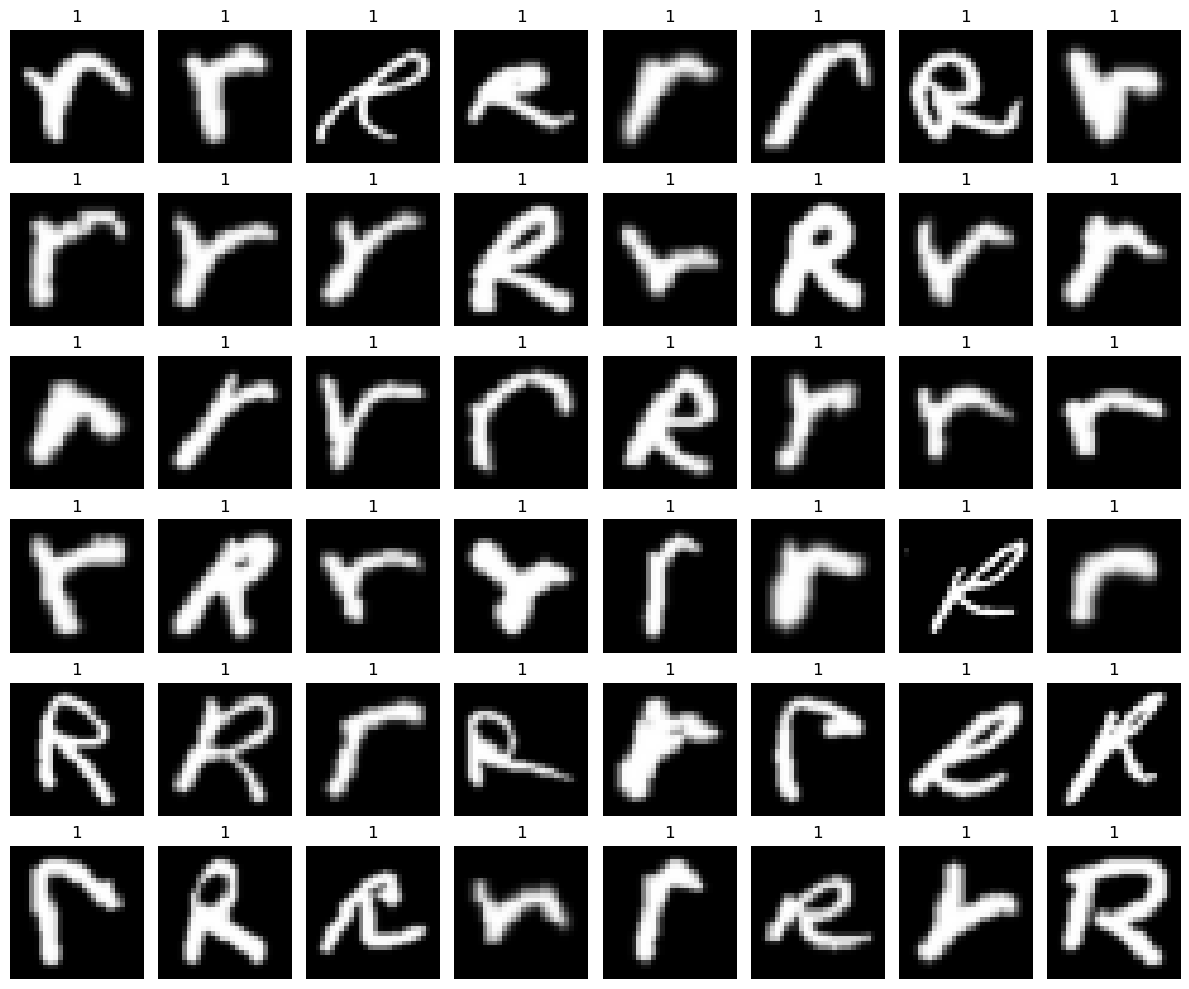

In [61]:
# Now check images after 3300 - will all have label 1

plot_grid(x_binary, y_binary, n=3300)

In [62]:
#Flattening image
x_binary = x_binary.reshape(x_binary.shape[0], -1).T  #(features x samples) format --> changing this format for feasible matrix multiplication
y_binary = y_binary.reshape(1, -1)                    #(1 x samples) format
y_binary_1d = y_binary.flatten()                      

In [63]:
#implementing train test val split
X_temp, X_test, Y_temp, Y_test = train_test_split(
    x_binary.T, y_binary_1d, test_size=0.2, random_state=42, stratify=y_binary_1d
)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_temp, Y_temp, test_size=0.25, random_state=42, stratify=Y_temp
) 


In [64]:
X_train, X_val, X_test = X_train.T, X_val.T, X_test.T   #getting back to original data format (samples x features)

In [65]:
Y_train = Y_train.reshape(1, -1)
Y_val   = Y_val.reshape(1, -1)
Y_test  = Y_test.reshape(1, -1)

In [66]:
print(f"X_train shape: {X_train.shape}, Y_train shape: {Y_train.shape}")

X_train shape: (784, 3960), Y_train shape: (1, 3960)


## Task 5: Deep Learning Enhancements